In [7]:
import pandas as pd

# Load dataset
df = pd.read_csv("../0_data/cleaned/duolingo_reviews_tagged.csv")

# Binary churn label: 1 for 1–2 stars, else 0
df['churn_risk'] = df['score'].apply(lambda x: 1 if x <= 2 else 0)

# One-hot encode feature mentions
feature_dummies = pd.get_dummies(df['feature_mentioned'], prefix='feat')

# Prepare final dataset
X = pd.concat([df[['sentiment_score', 'review_length']], feature_dummies], axis=1)
y = df['churn_risk']


In [8]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Evaluation
y_pred = model.predict(X_test)
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))


[[363   4]
 [ 22  11]]
              precision    recall  f1-score   support

           0       0.94      0.99      0.97       367
           1       0.73      0.33      0.46        33

    accuracy                           0.94       400
   macro avg       0.84      0.66      0.71       400
weighted avg       0.93      0.94      0.92       400



In [9]:
# Show model coefficients
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
}).sort_values(by='Coefficient', ascending=False)

coefficients.head(10)


,Feature,Coefficient
2,feat_ads,0.540414
3,feat_hearts,0.321702
6,feat_streaks,0.160510
7,feat_xp,0.125445
1,review_length,0.029926
4,feat_other,-0.490475
5,feat_owl,-0.658638
0,sentiment_score,-2.159254


In [10]:
import pandas as pd

# Load data
df = pd.read_csv("../0_data/cleaned/duolingo_reviews_tagged.csv")

# Convert date column
df['at'] = pd.to_datetime(df['at'])

# Group by week and calculate average sentiment
weekly_sentiment = df.groupby(pd.Grouper(key='at', freq='W'))['sentiment_score'].mean().reset_index()

# Rename for Prophet
weekly_sentiment.columns = ['ds', 'y']
weekly_sentiment = weekly_sentiment.dropna()
weekly_sentiment.head()


,ds,y
0,2025-04-27,0.439059
1,2025-05-04,0.450554


In [6]:
pip install prophet

  Using cached prophet-1.1.6-py3-none-win_amd64.whl.metadata (3.6 kB)
  Using cached cmdstanpy-1.2.5-py3-none-any.whl.metadata (4.0 kB)
  Using cached holidays-0.71-py3-none-any.whl.metadata (34 kB)
  Using cached stanio-0.5.1-py3-none-any.whl.metadata (1.6 kB)
Using cached prophet-1.1.6-py3-none-win_amd64.whl (13.3 MB)
Using cached cmdstanpy-1.2.5-py3-none-any.whl (94 kB)
Using cached holidays-0.71-py3-none-any.whl (917 kB)
Using cached stanio-0.5.1-py3-none-any.whl (8.1 kB)
Note: you may need to restart the kernel to use updated packages.


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 24.3.1 -> 25.1
[notice] To update, run: python.exe -m pip install --upgrade pip


15:55:23 - cmdstanpy - INFO - Chain [1] start processing
15:55:24 - cmdstanpy - INFO - Chain [1] done processing


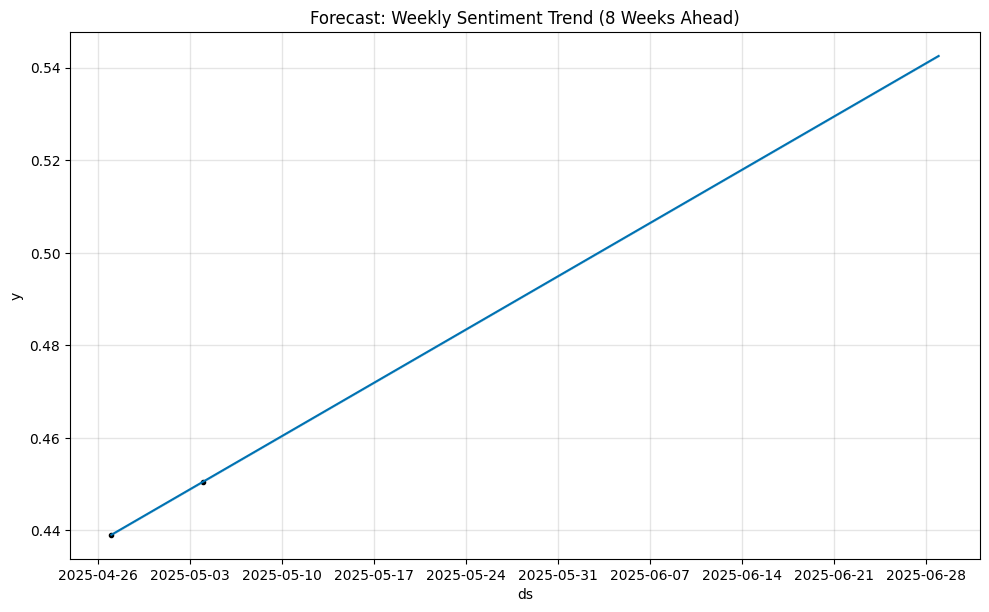

In [12]:
from prophet import Prophet
import matplotlib.pyplot as plt

model = Prophet()
model.fit(weekly_sentiment)

future = model.make_future_dataframe(periods=8, freq='W')
forecast = model.predict(future)

# Plot forecast
fig = model.plot(forecast)
plt.title("Forecast: Weekly Sentiment Trend (8 Weeks Ahead)")
plt.show()


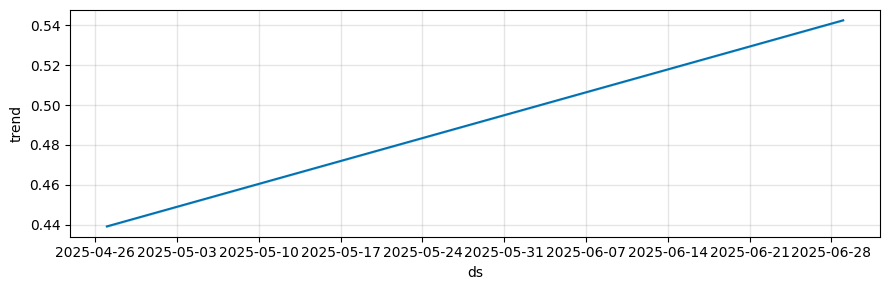

In [13]:
model.plot_components(forecast)
plt.show()


In [15]:
import pandas as pd

# Load your tagged review dataset
df = pd.read_csv("../0_data/cleaned/duolingo_reviews_tagged.csv")

# Define churn risk based on sentiment threshold
df['churn_risk'] = df['sentiment_score'].apply(lambda x: 1 if x < -0.05 else 0)

# Copy for simulation
df_sim = df.copy()

# Simulate: hearts are fixed — increase their sentiment score by 0.4
df_sim.loc[df_sim['feature_mentioned'] == 'hearts', 'sentiment_score'] += 0.4

# Cap sentiment between -1 and 1
df_sim['sentiment_score'] = df_sim['sentiment_score'].clip(-1, 1)

# Recalculate churn risk after fix
df_sim['churn_risk'] = df_sim['sentiment_score'].apply(lambda x: 1 if x < -0.05 else 0)

# Compare before vs after
original = df[df['feature_mentioned'] == 'hearts']['churn_risk'].mean()
simulated = df_sim[df_sim['feature_mentioned'] == 'hearts']['churn_risk'].mean()

print(f"🟥 Original churn risk (hearts): {original:.2f}")
print(f"🟩 Simulated churn risk (hearts fixed): {simulated:.2f}")


🟥 Original churn risk (hearts): 0.46
🟩 Simulated churn risk (hearts fixed): 0.29


In [16]:
df.to_csv("../0_data/exports/duolingo_final_dataset.csv", index=False)
df_sim.to_csv("../0_data/exports/duolingo_simulated_dataset.csv", index=False)
